# Кредитный скоринг

### Постановка задачи:

* выявить и обработать пропущенные значения и значения-заглушки;
* изучить основные характеристики признаков и их распределения;
* выявить некорректные значения и аномальные наблюдения;
* определить и обработать выбросы;
* при необходимости восстановить некорректные значения на основе имеющейся информации о клиенте;
* оценить влияние проведённой очистки на качество и структуру данных

## 1.1 Общий обзор

In [1]:
#загрузим библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
#считаем датасет
credit_df = pd.read_csv('../data/train.csv', index_col='ID')

C:\Users\79659\AppData\Local\Temp\ipykernel_4684\2268535609.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_df = pd.read_csv('../data/train.csv', index_col='ID')


In [3]:
#отобразим
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [4]:
# Проверим уникальные значения в столбце со смешанными типами данных
mixed_col = credit_df.columns[25]

print(f'Column: {mixed_col}')
print(credit_df[mixed_col].unique())

Column: Monthly_Balance
['312.49408867943663' '284.62916249607184' '331.2098628537912' ...
 516.8090832742814 319.1649785257098 393.6736955618808]


In [5]:
credit_df['Monthly_Balance'].value_counts(dropna=False)

Monthly_Balance
NaN                                 1200
__-333333333333333333333333333__       9
484.5912142650067                      1
393.673696                             1
312.49408867943663                     1
                                    ... 
300.008498                             1
396.997157                             1
368.154976                             1
412.669312                             1
432.559318                             1
Name: count, Length: 98793, dtype: int64

In [6]:
credit_df.loc[credit_df['Monthly_Balance'] == '__-333333333333333333333333333__']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x367f,CUS_0x9885,February,Paul Dayl,17,186-49-9679,Developer,41086.4,3660.866667,3,4,...,Standard,113.98,34.826541,11 Years and 6 Months,Yes,145.544320,201.1429928919469,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Standard
0xaf63,CUS_0x5a90,February,Scuffhamq,45,264-53-1943,Engineer,29728.31,2551.359167,3,4,...,Good,917.0,38.198076,31 Years and 9 Months,No,34.496445,198.6115126951797,Low_spent_Large_value_payments,__-333333333333333333333333333__,Good
0xc0d8,CUS_0x288d,July,Selamk,55,970-19-8342,Lawyer,30748.93,2572.410833,1,6,...,Good,860.97,40.634250,19 Years and 5 Months,No,43.727774,79.07180674947499,High_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xe66c,CUS_0x85e9,March,Anna Driveri,45,288-62-7562,_______,20929.295_,1704.107917,5,3,...,_,858.09,33.943626,21 Years and 7 Months,No,13798.000000,220.30455197823662,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0xf84c,CUS_0x2b77,July,Longstretho,21,006-36-0111,Doctor,15167.62,1471.968333,4,5,...,Good,847.03,28.541848,NaN,NM,9.930809,128.87587207680795,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1759f,CUS_0xc06e,February,radenp,30,046-72-5387,Journalist,92114.68,7811.223333,3,4,...,Standard,820.52,39.089475,20 Years and 10 Months,Yes,54.219664,NaN,High_spent_Large_value_payments,__-333333333333333333333333333__,Standard
0x1ceed,CUS_0x57f3,April,Kristen Haysq,29,577-85-0830,Mechanic,60904.59,NaN,3,4,...,Standard,2441.47,29.878716,12 Years and 11 Months,Yes,61.525140,394.8939566733383,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fbd8,CUS_0x41bf,July,Doeringq,44,693-64-7611,Journalist,61990.52,4900.876667,10,10,...,Bad,3618.91,37.718591,13 Years and 8 Months,NM,355.143396,194.28348839148083,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
0x1fdd1,CUS_0x2f7e,August,Sabina Zawadzkif,31,109-48-2095,Doctor,126353.04,10635.420000,4,7,...,_,859.77,28.442867,31 Years and 9 Months,No,167.043910,549.7661392945339,Low_spent_Medium_value_payments,__-333333333333333333333333333__,Poor


В признаке 'Monthly_Balance'  есть некорректные значения, которые вызывают предупреждения Pandas. Они будут обработаны позже.

In [7]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0x1602 to 0x25fed
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Name                      90015 non-null   object 
 3   Age                       100000 non-null  object 
 4   SSN                       100000 non-null  object 
 5   Occupation                100000 non-null  object 
 6   Annual_Income             100000 non-null  object 
 7   Monthly_Inhand_Salary     84998 non-null   float64
 8   Num_Bank_Accounts         100000 non-null  int64  
 9   Num_Credit_Card           100000 non-null  int64  
 10  Interest_Rate             100000 non-null  int64  
 11  Num_of_Loan               100000 non-null  object 
 12  Type_of_Loan              88592 non-null   object 
 13  Delay_from_due_date       100000 non-null  

В датафрейме 26 признаков и 1 целевая переменная и пропуски 8 столбцах.


- 0   ID                         - идентификатор
- 1   Customer_ID               - идентификатор клиента 
-  2   Month                     - месяц 
-  3   Name                      - имя 
- 4   Age                       - возраст 
- 5   SSN                       - номер социального страхования
- 6   Occupation                - род деятельности 
- 7   Annual_Income             - ежегодный доход 
- 8   Monthly_Inhand_Salary     - ежемесячный доход без учета налогов
- 9   Num_Bank_Accounts         - количество банковских аккаунтов
- 10  Num_Credit_Card           - номер кредитной карты
- 11  Interest_Rate             - процентная ставка 
- 12  Num_of_Loan               - количество кредитов 
- 13  Type_of_Loan              - тип кредита 
- 14  Delay_from_due_date       - задержка срока платежа
- 15  Num_of_Delayed_Payment    - количество задержек
- 16  Changed_Credit_Limit      - изменение кредитного лимита
- 17  Num_Credit_Inquiries      - количество запросов кредита
- 18  Credit_Mix                - кредит мик
- 19  Outstanding_Debt          - непогашенный долг
- 20  Credit_Utilization_Ratio  - коэффициент использования кредита
- 21  Credit_History_Age        - протяженности кредитной истории 
- 22  Payment_of_Min_Amount     - минимальный платеж 
- 23  Total_EMI_per_month       - равномерные ежемесячные платежи
- 24  Amount_invested_monthly   - ежемесячные инвестиции 
- 25  Payment_Behaviour         - платежное поведение
- 26  Monthly_Balance           - ежемесячный баланс 
- 27  Credit_Score              - кредитный рейтинг

Посмотрим статистики по разным столбцам в зависимости от типа и проверим на дубликаты.

In [8]:
print(f'Количество дубликатов: {credit_df.duplicated().sum()}')

Количество дубликатов: 0


In [9]:
credit_df.select_dtypes(include='number').describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [10]:
credit_df.select_dtypes(include='object').describe()

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,17273.83,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


* У ряда признаков с числовыми значениями тип данных определён как object, что требует предварительного преобразования типов.
* В данных присутствуют выбросы, аномальные и некорректные значения.
* Данные требуют преобразования, очистки и приведения признаков к корректным типам.
* Анализ и очистка будут проводиться отдельно для каждого признака с учётом его природы и оценкой распределения и статистики, где возможно.
* При обработке данных будет учитываться согласованность значений внутри каждого Customer_ID, что позволит выявлять некорректные значения и, где возможно, восстанавливать их на основе других наблюдений того же клиента.


## Анализ признаков

В датафрейме есть два признака идентификатора: Customer-ID и ID. Рассмотрим их.

In [11]:
print(f'Количество уникальных значений для Customer-ID: {len(credit_df['Customer_ID'].unique())}')
print(f'Количество пропусков для Custome-ID {credit_df['Customer_ID'].isna().sum()}')

Количество уникальных значений для Customer-ID: 12500
Количество пропусков для Custome-ID 0


In [12]:
print(f'Есть ли пропуски в индексе: {credit_df.index.hasnans}')
print(f'Содержатся ли в индексе уникальные значения: {credit_df.index.nunique()}')

Есть ли пропуски в индексе: False
Содержатся ли в индексе уникальные значения: 100000


**Выводы по признакам Custome-ID и ID**
- Датафрейм содержит данные о 12500 клиентах.
- В качестве индекса используется идентификтор - ID, уникальный для каждой строки. Он не информативен и его можно удалить без потери информации.
- Признак Custome-ID служит для идентификации клиента 

In [13]:
#посмотрим, сколько у нас уникальных значений в категории месяц
print(f'уникальный значений в категории месяц: {len(credit_df["Month"].unique())}')
print(*credit_df['Month'].unique(), sep='\n')

уникальный значений в категории месяц: 8
January
February
March
April
May
June
July
August


**Выводы по признаку Month**
- В датафрейме представленные данные 12500 клиентов за 8 месяцев.

In [14]:
#так как часть данных вметсо числовых форматов представлена в object напишем функцию для удаления нечисловых символов из количественных данных
def numeric(x):
    x = list(x)
    for i in x:
        if i in '.1234567890':
            continue
        else:
            x.remove(i)
    return ''.join(x)

In [15]:
#применим функцию numeric к столбцу age
credit_df['Age'] = credit_df['Age'].apply(numeric)
#поменяем тип данных категори возраст на int и посмотрим их распределение
credit_df['Age'] = credit_df['Age'].astype(int)

In [16]:
#проверим работу функции
credit_df['Age']

ID
0x1602      23
0x1603      23
0x1604     500
0x1605      23
0x1606      23
          ... 
0x25fe9     25
0x25fea     25
0x25feb     25
0x25fec     25
0x25fed     25
Name: Age, Length: 100000, dtype: int64

In [17]:
print(f'Количество пропусков в графе возраст {credit_df['Age'].isna().sum()}')

Количество пропусков в графе возраст 0


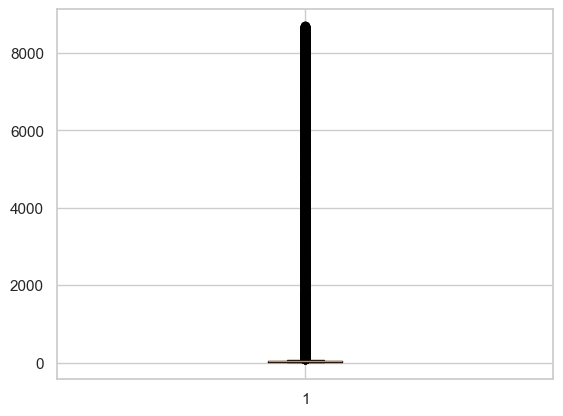

In [18]:
plt.boxplot(x='Age', data=credit_df)
plt.show()

In [19]:
credit_df['Age'].describe()

count    100000.000000
mean        119.509700
std         684.757313
min          14.000000
25%          25.000000
50%          34.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Статистики и боксплот показывают, что у нас скошенное распределение и большой хвост выбросов. Почистим данные: нужно удалить клиентов, чей возраст выходит за диапазон от нуля до сто десяти. Также проверить, чтобы у каждого клиента был один возраст или разница между возрастами была не более одного года, так как в датафрейме представлены данные за один год.

In [20]:
#отфильтруем возраст клиентов от 0 до 100, чтобы избавится от выбросов
age_df = credit_df[(credit_df['Age'] > 0) & (credit_df['Age'] <= 110)][['Age', 'Customer_ID']]
age_df = age_df.reset_index(drop=True).drop_duplicates()
age_df

,Age,Customer_ID
0,23,CUS_0xd40
7,28,CUS_0x21b1
15,34,CUS_0x2dbc
23,54,CUS_0xb891
25,55,CUS_0xb891
...,...,...
97207,50,CUS_0xaf61
97210,28,CUS_0x8600
97217,29,CUS_0x8600
97218,24,CUS_0x942c


In [21]:
age_df.groupby('Customer_ID')['Age'].nunique().sort_values(ascending=False).head()

Customer_ID
CUS_0xffd     2
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0xfb8     2
Name: Age, dtype: int64

In [22]:
problem_clients = age_df.groupby('Customer_ID')['Age'].nunique()
problem_clients = problem_clients[problem_clients > 1]

print(problem_clients)

Customer_ID
CUS_0x1000    2
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x1013    2
             ..
CUS_0xfe5     2
CUS_0xff4     2
CUS_0xff6     2
CUS_0xffc     2
CUS_0xffd     2
Name: Age, Length: 7205, dtype: int64


In [23]:
age_df.groupby('Customer_ID')['Age'].unique().loc[problem_clients.index]

Customer_ID
CUS_0x1000    [17, 18]
CUS_0x1009    [25, 26]
CUS_0x100b    [18, 19]
CUS_0x1011    [43, 44]
CUS_0x1013    [43, 44]
                ...   
CUS_0xfe5     [37, 38]
CUS_0xff4     [36, 37]
CUS_0xff6     [18, 19]
CUS_0xffc     [17, 18]
CUS_0xffd     [29, 30]
Name: Age, Length: 7205, dtype: object

Как мы можем видеть возраст у проблемных клиентов отличается на 1, скорее всего у клиента было день рождение. Соберем тех клиентов, у кого разница в дне рождении составляет больше 1 года.

In [24]:
(
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
    .value_counts()
)

Age
1     7198
0     5295
68       2
71       1
67       1
61       1
63       1
44       1
Name: count, dtype: int64

In [25]:
age_diff = (
    age_df.groupby('Customer_ID')['Age']
    .agg(lambda x: max(x) - min(x))
)

problem_ids = age_diff[age_diff > 1]

print(problem_ids)

Customer_ID
CUS_0x1dd3    71
CUS_0x3b9a    68
CUS_0x4b64    67
CUS_0x51cb    61
CUS_0x7e94    63
CUS_0xc24a    68
CUS_0xdc8     44
Name: Age, dtype: int64


In [26]:
age_df[
    age_df['Customer_ID'].isin(problem_ids.index)
].sort_values('Customer_ID')

,Age,Customer_ID
76379,24,CUS_0x1dd3
76383,95,CUS_0x1dd3
28505,32,CUS_0x3b9a
28509,100,CUS_0x3b9a
30437,102,CUS_0x4b64
30438,35,CUS_0x4b64
54630,48,CUS_0x51cb
54635,109,CUS_0x51cb
37191,95,CUS_0x7e94
37192,32,CUS_0x7e94


In [27]:
credit_df.loc[
    credit_df['Customer_ID'].isin(problem_ids.index),
    ['Customer_ID', 'Name', 'Age']
].sort_values(['Customer_ID', 'Age'])

,Customer_ID,Name,Age
ID,,,
0x1e252,CUS_0x1dd3,Gerryg,24
0x1e253,CUS_0x1dd3,Gerryg,24
0x1e254,CUS_0x1dd3,Gerryg,24
0x1e255,CUS_0x1dd3,Gerryg,24
0x1e257,CUS_0x1dd3,Gerryg,24
0x1e258,CUS_0x1dd3,Gerryg,24
0x1e259,CUS_0x1dd3,Gerryg,24
0x1e256,CUS_0x1dd3,Gerryg,95
0xc1c2,CUS_0x3b9a,NaN,32


In [28]:
#заменим некорекктные значения возраста
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x1dd3', 'Age'] = 24
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x3b9a', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x4b64', 'Age'] = 35
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x51cb', 'Age'] = 48
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x7e94', 'Age'] = 32
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xc24a', 'Age'] = 31
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xdc8', 'Age'] = 51


In [29]:
display(credit_df)

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1604,CUS_0xd40,March,Aaron Maashoh,500,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [30]:
rate_of_incorret_age = (1 - len(credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)])/len(credit_df))
print(f'Доля некорректных данных по возрасту: {rate_of_incorret_age:.2%}')

Доля некорректных данных по возрасту: 2.77%


Мы можем удалить некорректные данные, так как их величина не значительна.

In [31]:
credit_df = credit_df.loc[(credit_df['Age'] > 0) & (credit_df['Age'] < 105)]
credit_df = credit_df.copy()

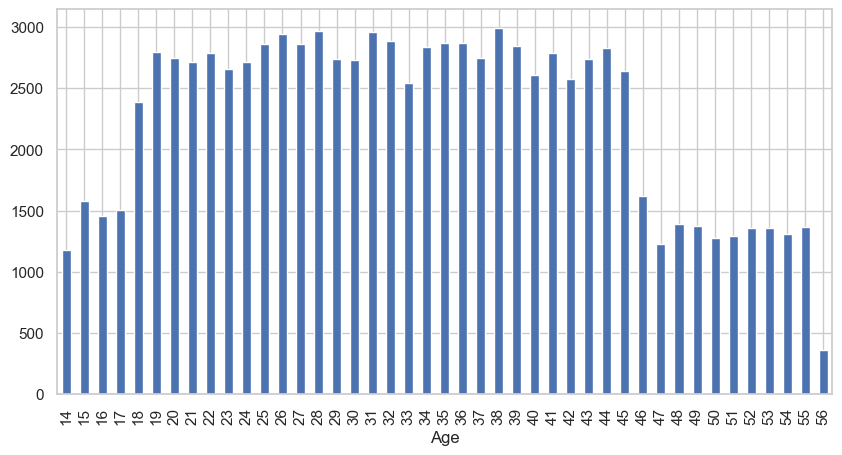

In [32]:
age_group = credit_df.groupby(by='Age')['Age'].count()
age_group.plot(kind='bar', grid=True, figsize=(10, 5))
plt.show()

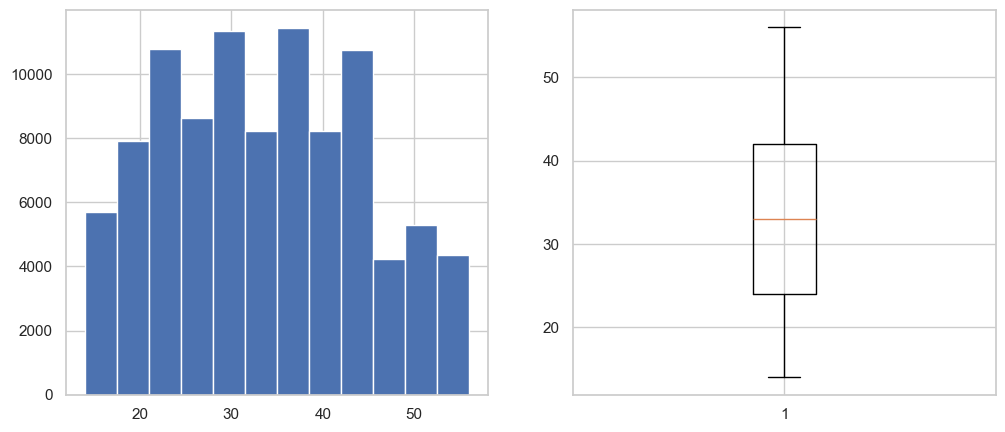

In [95]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(credit_df['Age'], bins=12)
ax2.boxplot(x='Age', data=credit_df)
plt.show()

In [35]:
credit_df['Age'].describe()

count    97227.000000
mean        33.320364
std         10.769517
min         14.000000
25%         24.000000
50%         33.000000
75%         42.000000
max         56.000000
Name: Age, dtype: float64

**Выводы по признаку Age** 
- Данные очищены от некорректных значений возраста: значений меньше 0 и превышающих 110 лет.
- Исправлены значения, возникшие вследствие некорректного представления возраста в исходных данных.
- После очистки средний возраст клиента составляет 33 года.
- Возраст клиентов в очищенном датасете находится в диапазоне от 14 до 56 лет.

In [36]:
#проверим данные по графе SSN
credit_df.groupby('SSN')['Name'].nunique().sort_values(ascending=False).head()

SSN
#F%$D@*&8      3809
998-47-8892       1
998-30-4976       1
000-63-0442       1
999-99-3421       1
Name: Name, dtype: int64

У 3809 строк значение похоже на ошибку или заглушку. Попробуем восстановить это значение из данных.

In [37]:
df_snn = credit_df.loc[credit_df['SSN'] == '#F%$D@*&8']

In [38]:
df_snn['Customer_ID']

ID
0x1609      CUS_0xd40
0x162b     CUS_0xb891
0x164d     CUS_0x284a
0x1650     CUS_0x284a
0x1694     CUS_0x3e45
              ...    
0x25f70    CUS_0x1619
0x25f98    CUS_0xad4f
0x25fa0    CUS_0x51b3
0x25fc2     CUS_0xf16
0x25fde    CUS_0x8600
Name: Customer_ID, Length: 5408, dtype: object

In [39]:
credit_df_filtered = credit_df[credit_df['Customer_ID'].isin(df_snn['Customer_ID'])]
credit_df_filtered

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fdd,CUS_0x8600,April,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,30.614953,5 Years and 11 Months,Yes,60.964772,43.72461709437765,High_spent_Large_value_payments,328.301277,Standard
0x25fde,CUS_0x8600,May,Sarah McBridec,28,#F%$D@*&8,Architect,20002.88,1929.906667,10,8,...,_,3571.7,28.508250,6 Years and 0 Months,Yes,60.964772,213.97800979403817,Low_spent_Small_value_payments,208.047884,Standard
0x25fdf,CUS_0x8600,June,Sarah McBridec,28,031-35-0942,_______,20002.88,1929.906667,10,8,...,Bad,3571.7,33.359987,6 Years and 1 Months,Yes,60.964772,74.36660309585342,!@9#%8,307.659291,Standard


In [40]:
credit_df_filtered.groupby('Customer_ID')['SSN'].nunique().sort_values(ascending=False)

Customer_ID
CUS_0xff3     2
CUS_0x1009    2
CUS_0x100b    2
CUS_0x1011    2
CUS_0x102e    2
             ..
CUS_0x10eb    2
CUS_0x10d7    2
CUS_0x10ac    2
CUS_0x10aa    2
CUS_0x109d    2
Name: SSN, Length: 4510, dtype: int64

In [41]:
ssn_counts = credit_df.groupby('Customer_ID')['SSN'].nunique()

ssn_counts_gt2 = ssn_counts[ssn_counts > 2].sort_values(ascending=False)

In [42]:
mask = credit_df['Customer_ID'].isin(ssn_counts.index)

valid_ssn = (
    credit_df[mask & (credit_df['SSN'] != '#F%$D@*&8')]
    .groupby('Customer_ID')['SSN']
    .first()
)

In [43]:
mask = (
    credit_df['Customer_ID'].isin(valid_ssn.index) &
    (credit_df['SSN'] == '#F%$D@*&8')
)

credit_df.loc[mask, 'SSN'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_ssn)
)

In [44]:
#проверяем результат замены
credit_df['SSN'].nunique()

12500

**выводы по признаку SSN**
- Проведен анализ случаев появления значения-заглушки #F%$D@*&8.
- Установлено, что появление заглушки носит единичный характер и не является систематической проблемой данных.
- Для клиентов, у которых значение SSN было представлено заглушкой, проведена проверка других записей по Customer_ID.
- Заглушки были заменены на валидные значения SSN соответствующего клиента на основании согласованности данных внутри Customer_ID.

In [45]:
print(*credit_df['Occupation'].unique(), sep="\n")

Scientist
_______
Teacher
Engineer
Entrepreneur
Developer
Lawyer
Media_Manager
Doctor
Journalist
Manager
Accountant
Musician
Mechanic
Writer
Architect


Посмотрим пропуски в профессиях.

In [46]:
credit_df.groupby('Customer_ID')['Occupation'].nunique().sort_values(ascending=False)

Customer_ID
CUS_0x1026    2
CUS_0xfd1     2
CUS_0xfdf     2
CUS_0xfe3     2
CUS_0xfe4     2
             ..
CUS_0x61a3    1
CUS_0x102e    1
CUS_0x1032    1
CUS_0x1037    1
CUS_0x1038    1
Name: Occupation, Length: 12500, dtype: int64

In [47]:
credit_df_filtered = credit_df[
    credit_df['Customer_ID'].isin(
        credit_df.groupby('Customer_ID')['Occupation']
                 .nunique()
                 .loc[lambda x: x == 2]
                 .index
    )
]

In [48]:
credit_df_filtered

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good
0x1610,CUS_0x21b1,March,Rick Rothackerj,28,004-07-5839,Teacher,34847.84_,3037.986667,2,1385,...,_,605.03,33.224951,26 Years and 9 Months,No,18.816215,58.51597569589465,High_spent_Large_value_payments,466.46647639764313,Standard
0x1611,CUS_0x21b1,April,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,NaN,2,4,...,Good,605.03,39.182656,26 Years and 10 Months,No,18.816215,99.30622796053305,Low_spent_Medium_value_payments,465.6762241330048,Good
0x1612,CUS_0x21b1,May,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,...,Good,605.03,34.977895,26 Years and 11 Months,No,18.816215,130.11542024292334,Low_spent_Small_value_payments,444.8670318506144,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fdd,CUS_0x8600,April,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,30.614953,5 Years and 11 Months,Yes,60.964772,43.72461709437765,High_spent_Large_value_payments,328.301277,Standard
0x25fde,CUS_0x8600,May,Sarah McBridec,28,031-35-0942,Architect,20002.88,1929.906667,10,8,...,_,3571.7,28.508250,6 Years and 0 Months,Yes,60.964772,213.97800979403817,Low_spent_Small_value_payments,208.047884,Standard
0x25fdf,CUS_0x8600,June,Sarah McBridec,28,031-35-0942,_______,20002.88,1929.906667,10,8,...,Bad,3571.7,33.359987,6 Years and 1 Months,Yes,60.964772,74.36660309585342,!@9#%8,307.659291,Standard


In [49]:
valid_occupation = (
    credit_df[credit_df['Occupation'] != '_______']
    .groupby('Customer_ID')['Occupation']
    .first()
)

In [50]:
mask = credit_df['Occupation'] == '_______'

credit_df.loc[mask, 'Occupation'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_occupation)
)

In [51]:
credit_df

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor


In [52]:
print(*credit_df['Occupation'].unique(), sep="\n")

Scientist
Teacher
Engineer
Entrepreneur
Developer
Lawyer
Media_Manager
Doctor
Journalist
Manager
Accountant
Musician
Mechanic
Writer
Architect


**выводы по признаку Occupation**
- заглушка "____" заменена на валидную профессию каждого клиента

In [53]:
#Annual Income
credit_df['Annual_Income'] = credit_df['Annual_Income'].apply(numeric)
credit_df['Annual_Income'] = credit_df['Annual_Income'].astype(float)

In [54]:
credit_df['Annual_Income'].describe()

count    9.722700e+04
mean     1.768399e+05
std      1.432660e+06
min      7.005930e+03
25%      1.946292e+04
50%      3.757975e+04
75%      7.281702e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

In [55]:
credit_df.loc[credit_df['Annual_Income'] == credit_df['Annual_Income'].max()]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x13104,CUS_0xcfc,July,Catherine Bosleyz,31,555-99-1654,Engineer,24198062.0,1135.525417,4,5,...,Good,672.49,34.790192,18 Years and 4 Months,No,46.388945,53.57386255067172,Low_spent_Large_value_payments,283.58973432257824,Good


In [56]:
credit_df[credit_df['Customer_ID'] == 'CUS_0xcfc']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x130fe,CUS_0xcfc,January,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,NaN,4,5,...,Good,672.49,37.008636,17 Years and 10 Months,No,46.388945,139.36742966998645,Low_spent_Small_value_payments,217.79616720326354,Good
0x130ff,CUS_0xcfc,February,NaN,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,Good,672.49,34.865078,17 Years and 11 Months,No,46.388945,69.4070447487928,Low_spent_Small_value_payments,287.7565521244572,Good
0x13100,CUS_0xcfc,March,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,_,672.49,32.991519,NaN,No,46.388945,65.97411958788724,Low_spent_Small_value_payments,291.1894772853627,Standard
0x13101,CUS_0xcfc,April,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,NaN,4,5,...,Good,672.49,37.551313,18 Years and 1 Months,No,46.388945,39.63190519155351,High_spent_Medium_value_payments,277.5316916816965,Good
0x13102,CUS_0xcfc,May,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,715,745,...,Good,672.49,26.381751,18 Years and 2 Months,No,46.388945,__10000__,Low_spent_Small_value_payments,293.6610909711095,Standard
0x13103,CUS_0xcfc,June,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,106,...,Good,672.49,31.863006,18 Years and 3 Months,No,46.388945,76.12271276870344,Low_spent_Small_value_payments,281.04088410454654,Good
0x13104,CUS_0xcfc,July,Catherine Bosleyz,31,555-99-1654,Engineer,2.419806e+07,1135.525417,4,5,...,Good,672.49,34.790192,18 Years and 4 Months,No,46.388945,53.57386255067172,Low_spent_Large_value_payments,283.58973432257824,Good
0x13105,CUS_0xcfc,August,Catherine Bosleyz,31,555-99-1654,Engineer,1.533031e+04,1135.525417,4,5,...,Good,672.49,25.389565,18 Years and 5 Months,NM,46.388945,118.63218351505384,Low_spent_Small_value_payments,238.53141335819612,Standard


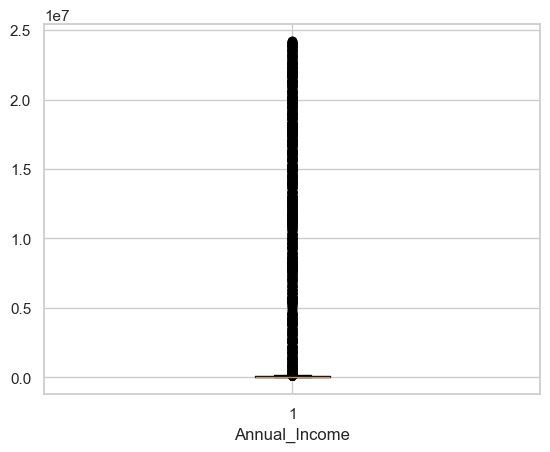

In [57]:
plt.boxplot(x='Annual_Income', data=credit_df)
plt.xlabel('Annual_Income')
plt.show()

In [58]:
income_check = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .nunique()
    .sort_values(ascending=False)
)

income_check[income_check > 1]

Customer_ID
CUS_0x58e3    4
CUS_0xc1fa    4
CUS_0x40e5    3
CUS_0x2748    3
CUS_0x473f    3
             ..
CUS_0xee1     2
CUS_0xf20     2
CUS_0xf55     2
CUS_0x1018    2
CUS_0xfa4     2
Name: Annual_Income, Length: 944, dtype: int64

In [59]:
income_check = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .unique()
)

income_check[income_check.apply(len) > 1]

Customer_ID
CUS_0x1018    [61194.81, 17117486.0]
CUS_0x1057     [86617.16, 1105753.0]
CUS_0x107e    [75095.91, 15741145.0]
CUS_0x108a    [36982.36, 11641815.0]
CUS_0x10a9    [17603.265, 9032145.0]
                       ...          
CUS_0xe5b     [43568.84, 17488375.0]
CUS_0xee1     [14630332.0, 17116.55]
CUS_0xf20     [58063.48, 20189519.0]
CUS_0xf55     [78443.48, 20350298.0]
CUS_0xfa4      [15035.19, 7711339.0]
Name: Annual_Income, Length: 944, dtype: object

In [90]:
credit_df['Annual_Income'] = (
    credit_df.groupby('Customer_ID')['Annual_Income']
    .transform(lambda x: x.mode().iloc[0])
)

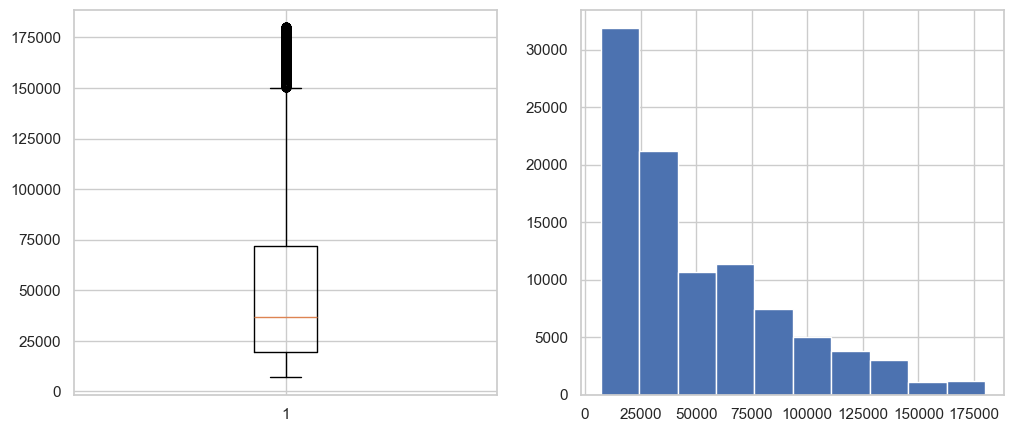

In [93]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.boxplot(x='Annual_Income', data=credit_df)
ax2.hist(x='Annual_Income', data=credit_df)
plt.show()

После заполнения графы ежегодный доход модой по каждому клиенту мы получили левое логнормальное распределение, характерное для зарплат. 

In [63]:
#посмотрим ежегодный и ежемесячный доход по профессиям
occupation_annual_income_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary']).round(2).sort_values(by='Annual_Income')

In [64]:
occupation_annual_income_df

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Journalist,48599.38,4026.48
Doctor,49467.54,4110.93
Lawyer,49502.06,4121.82
Teacher,49754.93,4124.63
Mechanic,50095.08,4139.25
Developer,50176.72,4159.15
Engineer,50649.58,4234.41
Media_Manager,50670.85,4214.80
Accountant,50711.25,4209.92


In [65]:
occupation_annual_income_median_df = credit_df.pivot_table(index='Occupation', 
                                                    values=['Annual_Income', 
                                                            'Monthly_Inhand_Salary'], aggfunc='median').round(2)

In [66]:
#посмотрим медиану
occupation_annual_income_median_df.sort_values(by='Annual_Income', ascending=False)

,Annual_Income,Monthly_Inhand_Salary
Occupation,,
Scientist,39487.82,3260.46
Engineer,39020.72,3201.51
Musician,38480.95,3130.68
Manager,38443.42,3245.01
Accountant,38391.66,3202.14
Architect,37827.77,3152.07
Writer,37769.92,3154.64
Entrepreneur,37482.37,3116.89
Media_Manager,36980.10,3138.63


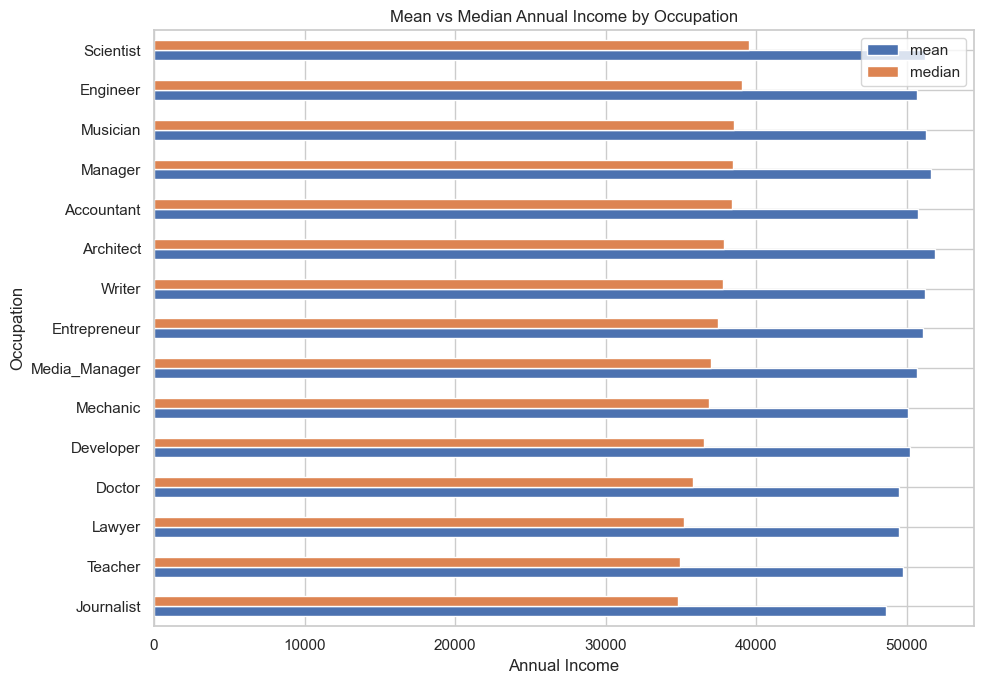

In [67]:
occupation_income = (
    credit_df.groupby('Occupation')['Annual_Income']
    .agg(['mean', 'median'])
    .sort_values('median')
)

ax = occupation_income.plot(
    kind='barh',
    figsize=(10, 7)
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Occupation')
ax.set_title('Mean vs Median Annual Income by Occupation')
plt.tight_layout()
plt.show()

Мы видим, что по всем профессия больше медианы. Более того, если сравнить медианы и средние, то порядок профессии меняется. Это говорит о том, что в некоторых профессия несколько высокооплачиваемых специалистов сдвигают среднее вправо. Главный вывод - среднее плохо годится, как описательная статистика для этого признака. Необходимо использовать медиану.

**Выводы по анализу признака Annual_Income**
- Некорректные значения Annual_Income были восстановлены с использованием моды годового дохода для каждого клиента.
- По графикам распределения Annual_Income наблюдается правосторонняя асимметрия, характерная для распределений доходов: основная масса наблюдений сосредоточена в области относительно невысоких значений, при этом присутствует правый хвост высоких доходов.
При сравнении среднего и медианы обнаружено, что среднее значение стабильно превышает медиану для всех профессий. Это указывает на влияние высоких значений дохода на среднее.
- Особенно заметен разрыв между средним и медианным доходом в профессиях с относительно низким типичным уровнем дохода: наличие отдельных высокооплачиваемых клиентов смещает среднее значение вправо.
- В связи с этим медиана является более устойчивой и репрезентативной характеристикой типичного дохода клиента, чем среднее значение.

In [68]:
credit_df['Num_Bank_Accounts'].describe()

count    97227.000000
mean        17.127722
std        117.685312
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

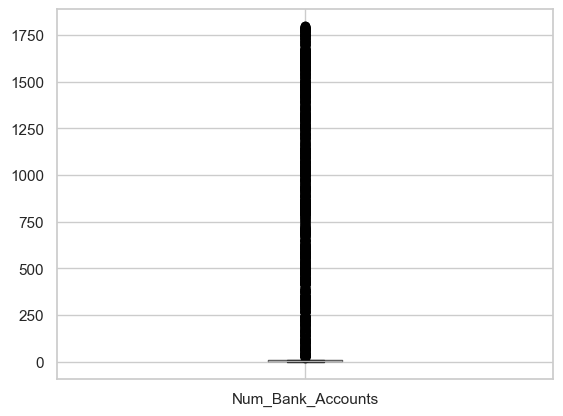

In [69]:
credit_df[['Num_Bank_Accounts']].boxplot()
plt.show()

Видим на графие большой хвост выбросов, а также то, что у нас есть отрицательное значение -1 и максимальное 1798. Проанализируем максимальные и минимальные значения. Посмотрим общее количество банковских аккаунтов.

In [70]:
credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x1791,CUS_0x4004,April,Carlosj,44,679-26-6464,Writer,58317.00,NaN,1414,5,...,Standard,98.97,29.766107,NaN,Yes,149.897199,158.64827595455043,High_spent_Medium_value_payments,407.9295246244412,Standard
0x17d0,CUS_0x42ac,July,Lawrencea,37,700-60-3660,Musician,15566.02,1423.168333,67,5,...,Standard,1693.95,29.706454,8 Years and 4 Months,Yes,43.070520,80.48442010154183,!@9#%8,308.76189362947565,Poor
0x17fd,CUS_0x9bc1,April,Jaisinghanij,42,445-18-4420,Architect,20574.47,NaN,572,3,...,Standard,749.95,36.559538,11 Years and 2 Months,Yes,49.348666,25.161404432750263,High_spent_Medium_value_payments,349.54384591241774,Standard
0x1816,CUS_0xaedb,May,Olivia Oranr,19,272-47-1135,Musician,85554.03,7185.502500,1488,2,...,_,1095.73,41.661802,19 Years and 11 Months,No,0.000000,70.82263261910934,High_spent_Large_value_payments,887.7276173808908,Good
0x1a6e,CUS_0x8643,May,Steve Slatery,33,198-08-9791,Musician,14205.09,1086.757500,91,10,...,Bad,4845.24,30.989504,NaN,Yes,49.032395,64.58804984795468,Low_spent_Large_value_payments,265.05530468293233,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0x25d89,CUS_0x544,August,Jon Herskovitzu,29,163-45-1172,Mechanic,17013.29,1326.774167,813,1,...,_,1452.79,28.051684,32 Years and 6 Months,NM,13.109663,55.72695329443804,Low_spent_Small_value_payments,353.840801,Good
0x25dd0,CUS_0x296f,July,David Millikenh,25,972-13-0672,Developer,125271.96,10374.330000,1481,7,...,Good,827.56,33.201730,25 Years and 8 Months,NM,241.065885,180.56001463373025,!@9#%8,855.8071,Poor
0x25dfc,CUS_0xb09,March,Lianau,31,228-47-4867,Lawyer,146310.68,12124.556667,474,4,...,Good,928.28,43.274889,22 Years and 3 Months,No,72.250125,121.28482498252883,High_spent_Large_value_payments,1258.920717,Standard


In [71]:
result = (
    credit_df.loc[credit_df['Num_Bank_Accounts'] > 20]
    .groupby('Customer_ID')['Num_Bank_Accounts']
    .unique()
)

result[result.apply(len) > 1]

Customer_ID
CUS_0x112e        [1678, 1352]
CUS_0x138d          [230, 162]
CUS_0x14ce     [761, 569, 955]
CUS_0x16d5         [1153, 239]
CUS_0x19e1          [907, 205]
CUS_0x1b66          [211, 385]
CUS_0x1e2d          [201, 334]
CUS_0x1e3e         [1325, 290]
CUS_0x1eea          [550, 501]
CUS_0x1f2f        [1146, 1411]
CUS_0x22b9        [1751, 1503]
CUS_0x24d4         [857, 1714]
CUS_0x28e2    [295, 1668, 354]
CUS_0x2999         [936, 1620]
CUS_0x29b1        [1506, 1472]
CUS_0x3359        [1041, 1404]
CUS_0x3b37         [1549, 848]
CUS_0x3d99         [1617, 566]
CUS_0x4190          [921, 364]
CUS_0x48aa        [1312, 1315]
CUS_0x4dd5         [445, 1168]
CUS_0x5499         [527, 1350]
CUS_0x59f1          [1236, 59]
CUS_0x5b57          [264, 194]
CUS_0x61b7          [322, 628]
CUS_0x6273          [734, 511]
CUS_0x6397         [112, 1561]
CUS_0x746c          [1078, 64]
CUS_0x7aae          [324, 406]
CUS_0x7dfb          [741, 121]
CUS_0x7f0a          [179, 844]
CUS_0x836e         [1583, 3

Эти банковские аккаунты невозможно восстановить из имеющихся данных: в них только невалидные значения для данной графы. Их мало и их удалю.

In [72]:
problem_customers = result[result.apply(len) > 1].index

credit_df = credit_df[
    ~credit_df['Customer_ID'].isin(problem_customers)
]
credit_df = credit_df.copy()

In [73]:
credit_df.loc[credit_df['Num_Bank_Accounts'] < 0]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
0xc7b9,CUS_0x4f2a,April,Margaretf,40,807-03-5415,Engineer,128305.76,NaN,-1,6,...,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,128305.76,NaN,-1,6,...,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good
0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,37.286105,20 Years and 6 Months,No,0.000000,668.1444536762707,!@9#%8,588.9477963237292,Poor
0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.915627,20 Years and 7 Months,No,0.000000,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.922500,-1,6,...,Good,607.78,41.799942,20 Years and 8 Months,No,0.000000,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor


In [74]:
credit_df[credit_df['Num_Bank_Accounts'] == 1798]

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x8ccf,CUS_0x7fd9,June,en Deightono,55,165-28-2986,Accountant,32946.22,NaN,1798,7,...,Good,1330.02,21.743562,18 Years and 0 Months,No,46.244585,264.3665957522356,Low_spent_Large_value_payments,245.94065263077442,Standard
0x19027,CUS_0x11c1,February,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,1798,3,...,Standard,533.71,34.380248,19 Years and 9 Months,Yes,66.210327,282.83977688221506,Low_spent_Small_value_payments,164.03506268873434,Standard


In [75]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x7fd9']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x8cca,CUS_0x7fd9,January,NaN,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,33.741883,17 Years and 7 Months,No,46.244585,41.0222288776369,High_spent_Large_value_payments,439.28501950537293,Standard
0x8ccb,CUS_0x7fd9,February,en Deightono,55,165-28-2986,Accountant,32946.22,NaN,0,7,...,Good,1330.02,37.601963,17 Years and 8 Months,NM,46.244585,34.13407212736563,High_spent_Large_value_payments,446.17317625564436,Standard
0x8ccc,CUS_0x7fd9,March,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,_,1330.02,23.481559,17 Years and 9 Months,NM,46.244585,368.7055196194469,Low_spent_Small_value_payments,161.6017287635631,Standard
0x8cce,CUS_0x7fd9,May,en Deightono,55,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,33.743120,17 Years and 11 Months,No,46.244585,110.35298021862238,High_spent_Medium_value_payments,379.9542681643876,Standard
0x8ccf,CUS_0x7fd9,June,en Deightono,55,165-28-2986,Accountant,32946.22,NaN,1798,7,...,Good,1330.02,21.743562,18 Years and 0 Months,No,46.244585,264.3665957522356,Low_spent_Large_value_payments,245.94065263077442,Standard
0x8cd0,CUS_0x7fd9,July,en Deightono,56,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,_,1330.02,25.276571,18 Years and 1 Months,No,46.244585,168.49692256371287,Low_spent_Large_value_payments,341.81032581929713,Standard
0x8cd1,CUS_0x7fd9,August,en Deightono,56,165-28-2986,Accountant,32946.22,2865.518333,0,7,...,Good,1330.02,35.871065,18 Years and 2 Months,NM,46.244585,226.873707316444,Low_spent_Small_value_payments,303.433541066566,Standard


In [76]:
credit_df[credit_df['Customer_ID'] == 'CUS_0x11c1']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x19026,CUS_0x11c1,January,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,28.449959,19 Years and 8 Months,Yes,66.210327,173.75926050258002,Low_spent_Small_value_payments,273.11557906836936,Standard
0x19027,CUS_0x11c1,February,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,1798,3,...,Standard,533.71,34.380248,19 Years and 9 Months,Yes,66.210327,282.83977688221506,Low_spent_Small_value_payments,164.03506268873434,Standard
0x19028,CUS_0x11c1,March,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,38.700394,19 Years and 10 Months,Yes,66.210327,141.6147987112849,!@9#%8,275.2600408596645,Standard
0x19029,CUS_0x11c1,April,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,31.355523,19 Years and 11 Months,Yes,66.210327,47.77036669728128,High_spent_Medium_value_payments,359.10447287366816,Standard
0x1902a,CUS_0x11c1,May,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,31.277406,20 Years and 0 Months,Yes,66.210327,115.02505043046536,Low_spent_Medium_value_payments,321.84978914048406,Standard
0x1902b,CUS_0x11c1,June,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,32.290532,20 Years and 1 Months,Yes,66.210327,204.57678263227075,Low_spent_Large_value_payments,222.2980569386787,Standard
0x1902c,CUS_0x11c1,July,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,25.404598,20 Years and 2 Months,NM,66.210327,205.67758345658862,!@9#%8,241.1972561143608,Standard
0x1902d,CUS_0x11c1,August,Mark Felsenthalk,34,688-99-5258,Engineer,29902.22,2230.851667,6,3,...,Standard,533.71,38.321831,NaN,Yes,66.210327,44.11332027545772,!@9#%8,352.7615192954917,Standard


In [77]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x4f2a']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0xc7b6,CUS_0x4f2a,January,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,...,Good,1151.7,28.555646,22 Years and 3 Months,No,196.587321,268.7720817598091,High_spent_Medium_value_payments,828.0552637408804,Standard
0xc7b7,CUS_0x4f2a,February,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,0,7,...,Good,1151.7,30.343064,22 Years and 4 Months,No,196.587321,588.7732847049177,Low_spent_Small_value_payments,548.0540607957716,Standard
0xc7b8,CUS_0x4f2a,March,Margaretf,39,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,40.586736,22 Years and 5 Months,No,196.587321,230.9223857499363,High_spent_Large_value_payments,855.9049597507532,Standard
0xc7b9,CUS_0x4f2a,April,Margaretf,40,807-03-5415,Engineer,128305.76,NaN,-1,6,...,Good,1151.7_,39.369401,22 Years and 6 Months,No,196.587321,524.3044177743545,Low_spent_Large_value_payments,592.522927726335,Good
0xc7ba,CUS_0x4f2a,May,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,28.702053,22 Years and 7 Months,No,196.587321,150.0966753535676,High_spent_Large_value_payments,936.7306701471217,Good
0xc7bb,CUS_0x4f2a,June,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,34.808390,22 Years and 8 Months,No,196.587321,1006.6980690205388,Low_spent_Medium_value_payments,120.12927648015079,Good
0xc7bc,CUS_0x4f2a,July,Margaretf,40,807-03-5415,Engineer,128305.76,10434.146667,-1,6,...,Good,1151.7,35.206427,NaN,No,42850.000000,172.99202124673786,High_spent_Large_value_payments,913.8353242539515,Good
0xc7bd,CUS_0x4f2a,August,Margaretf,40,807-03-5415,Engineer,128305.76,NaN,-1,6,...,_,1151.7,38.278518,22 Years and 10 Months,No,196.587321,338.67230317776176,High_spent_Medium_value_payments,758.1550423229277,Good


Здесь мы видим вероятную причину возникновения -1 в количестве банковских счетов. Если в системе указано нулевое количество банковских счетов, а количество кредитных карт уменьшается на единицу, то вычетание из 0 единицы дает -1. Проверим эту теорию.

In [78]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0xa878']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x115fe,CUS_0xa878,January,NaN,54,300-54-4627,Engineer,117851.07,9870.9225,0,7,...,_,607.78,31.531889,20 Years and 5 Months,No,0.0,394.2919200897653,High_spent_Medium_value_payments,842.8003299102347,Poor
0x115ff,CUS_0xa878,February,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,37.286105,20 Years and 6 Months,No,0.0,668.1444536762707,!@9#%8,588.9477963237292,Poor
0x11600,CUS_0xa878,March,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,41.915627,20 Years and 7 Months,No,0.0,142.31978881674561,High_spent_Large_value_payments,1084.7724611832548,Poor
0x11601,CUS_0xa878,April,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,41.799942,20 Years and 8 Months,No,0.0,467.563922615828,High_spent_Small_value_payments,779.528327384172,Poor
0x11602,CUS_0xa878,May,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,46.244581,20 Years and 9 Months,No,0.0,NaN,High_spent_Large_value_payments,1037.5063384360787,Poor
0x11603,CUS_0xa878,June,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,32.303737,20 Years and 10 Months,No,0.0,218.00522319835895,High_spent_Medium_value_payments,1019.0870268016413,Poor
0x11604,CUS_0xa878,July,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,30.709169,20 Years and 11 Months,No,0.0,352.80115804899873,High_spent_Medium_value_payments,884.2910919510015,Poor
0x11605,CUS_0xa878,August,Douwe Miedemaz,54,300-54-4627,Engineer,117851.07,9870.9225,-1,6,...,Good,607.78,34.041733,21 Years and 0 Months,No,0.0,467.41582464616476,High_spent_Small_value_payments,779.6764253538355,Poor


In [79]:
credit_df.loc[credit_df['Customer_ID'] == 'CUS_0x5993']

,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
ID,,,,,,,,,,,,,,,,,,,,,
0x15bfb,CUS_0x5993,February,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,0,5,...,Good,644.57,30.230648,NaN,No,16.483566,143.32297249655755,High_spent_Small_value_payments,331.9277112802258,Standard
0x15bfc,CUS_0x5993,March,Stephensonq,40,120-48-2348,Developer,30352.11,NaN,0,5,...,_,644.57,38.822428,23 Years and 7 Months,No,16.483566,60.681955753649085,High_spent_Small_value_payments,414.5687280231343,Standard
0x15bfd,CUS_0x5993,April,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,0,5,...,Good,644.57,36.351893,23 Years and 8 Months,NM,16.483566,54.56979945313372,High_spent_Large_value_payments,400.6808843236496,Standard
0x15bfe,CUS_0x5993,May,Stephensonq,40,120-48-2348,Developer,30352.11,2317.3425,-1,165,...,Good,644.57,25.532001,23 Years and 9 Months,NM,16.483566,126.66534532381421,Low_spent_Medium_value_payments,368.5853384529692,Standard
0x15bff,CUS_0x5993,June,NaN,40,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,31.813259,23 Years and 10 Months,No,16.483566,54.82132668337657,High_spent_Large_value_payments,400.42935709340685,Standard
0x15c00,CUS_0x5993,July,Stephensonq,41,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,26.574175,23 Years and 11 Months,No,16.483566,64.86083753440263,!@9#%8,400.38984624238066,Standard
0x15c01,CUS_0x5993,August,NaN,41,120-48-2348,Developer,30352.11,2317.3425,-1,4,...,Good,644.57,32.937399,24 Years and 0 Months,No,16.483566,89.62296249058659,High_spent_Medium_value_payments,375.62772128619685,Standard


Да, причина выявлена. Можно дать рекомендацию разработчикам баз данных проверить код, связанный с этой ошибкой. Значение -1 можно заменить на значение ноль по всему датафрейму.

In [80]:
credit_df['Num_Bank_Accounts'] = credit_df['Num_Bank_Accounts'].replace(-1, 0)

Теперь оценим максимальное количество банковских счетов. Посмотрим, есть ли у клиентов, кроме запредельного количества счетов, и валидные значения. Если большое количество единично, то считаем его ошибкой и заменяем валидным значением для клиента из его других граф.

In [81]:
credit_df['Num_Bank_Accounts'].describe()

count    96805.000000
mean        16.210857
std        113.146832
min          0.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [82]:
result = (
    credit_df.groupby('Customer_ID')['Num_Bank_Accounts']
    .agg(['nunique', 'max'])
)

result = result[
    (result['nunique'] >= 2) &
    (result['max'] > 20)
]
result

,nunique,max
Customer_ID,,
CUS_0x102d,2,1000
CUS_0x104a,2,124
CUS_0x109d,2,232
CUS_0x109f,2,561
CUS_0x10a9,2,1725
...,...,...
CUS_0xf01,2,782
CUS_0xf19,2,1763
CUS_0xf2e,2,1634


In [83]:
result = (
    credit_df.groupby('Customer_ID')['Num_Bank_Accounts']
    .unique()
)

result = result[
    result.apply(lambda x: len(x) >= 2 and any(v > 20 for v in x))
]
result

Customer_ID
CUS_0x102d      [5, 1000]
CUS_0x104a       [2, 124]
CUS_0x109d      [10, 232]
CUS_0x109f       [4, 561]
CUS_0x10a9      [8, 1725]
                 ...     
CUS_0xf01        [0, 782]
CUS_0xf19       [5, 1763]
CUS_0xf2e      [10, 1634]
CUS_0xf43       [8, 1644]
CUS_0xfac     [5, 6, 796]
Name: Num_Bank_Accounts, Length: 1170, dtype: object

In [84]:
valid_values = (
    credit_df[credit_df['Num_Bank_Accounts'] < 21]
    .groupby('Customer_ID')['Num_Bank_Accounts']
    .first()
)

In [85]:
mask = (
    credit_df['Customer_ID'].isin(result.index) &
    (credit_df['Num_Bank_Accounts'] >= 21)
)

credit_df.loc[mask, 'Num_Bank_Accounts'] = (
    credit_df.loc[mask, 'Customer_ID'].map(valid_values)
)

In [86]:
credit_df['Num_Bank_Accounts'].describe()

count    96805.000000
mean         5.368969
std          2.592616
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         18.000000
Name: Num_Bank_Accounts, dtype: float64

**Выводы по признаку Num_Bank_Accounts**
- Выявлены клиенты с аномально высоким количеством банковских аккаунтов; такие наблюдения были исключены из дальнейшего анализа.
- Для клиентов, у которых встречалось единичное аномально высокое значение, проведена проверка остальных записей клиента.
- Если у клиента было доступно валидное значение Num_Bank_Accounts, аномальное значение было заменено на него.
- Клиенты, для которых не удалось определить корректное значение, были исключены из датасета.
- Значение -1 вызывано некорректной обработкой связи количества кредитных карт и количества банковских аккаунтов. При уменьшении кредитных карт на единицу и нулевом значении банковских аккаунтов, количество банковских аккаунтов менялось на -1.
- значение -1 было заменено на 0 по всему датафрейму

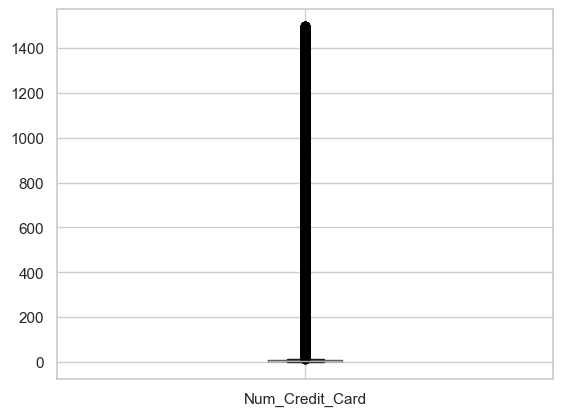

In [100]:
credit_df[['Num_Credit_Card']].boxplot()
plt.show()

In [101]:
credit_df['Num_Credit_Card'].describe()

count    96805.000000
mean        22.464170
std        128.921551
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max       1499.000000
Name: Num_Credit_Card, dtype: float64

- Отрицательных значений нет.
- Есть выбросы